# Data Load

In [2]:
import pandas as pd
import numpy as np
import os


xlsx_path = './AD_DECODE_data3.xlsx'
df = pd.read_excel(xlsx_path)

df = df[(df['MRI_Exam'] != '0') & (df['MRI_Exam'] != '4491')& (df['MRI_Exam'] != '3866')]
df = df.dropna(subset = ['MRI_Exam'])

fa_dict = {}

# 
base_dir = './input_columns_1mm/input_columns'

for exam in df['MRI_Exam']:
    try:
        exam_int = int(float(exam)) 
        exam_str = str(exam_int).zfill(4)  
        subject_id = f"{exam_str}"
        
        fa_path = os.path.join(base_dir, f"S0{subject_id}_columns_1mm", f"S0{subject_id}_fa.csv")
        
        if os.path.exists(fa_path):
            fa_values = np.loadtxt(fa_path, delimiter=',')
            fa_dict[subject_id] = fa_values
        else:
            print(f"File not found: {fa_path}")
    except Exception as e:
        print(f"Error with MRI_Exam = {exam}: {e}")


File not found: ./input_columns_1mm/input_columns\S02469_columns_1mm\S02469_fa.csv
File not found: ./input_columns_1mm/input_columns\S02289_columns_1mm\S02289_fa.csv
File not found: ./input_columns_1mm/input_columns\S02266_columns_1mm\S02266_fa.csv
File not found: ./input_columns_1mm/input_columns\S02686_columns_1mm\S02686_fa.csv
File not found: ./input_columns_1mm/input_columns\S02812_columns_1mm\S02812_fa.csv
File not found: ./input_columns_1mm/input_columns\S02842_columns_1mm\S02842_fa.csv
File not found: ./input_columns_1mm/input_columns\S02224_columns_1mm\S02224_fa.csv
File not found: ./input_columns_1mm/input_columns\S02871_columns_1mm\S02871_fa.csv
File not found: ./input_columns_1mm/input_columns\S03321_columns_1mm\S03321_fa.csv
File not found: ./input_columns_1mm/input_columns\S03867_columns_1mm\S03867_fa.csv
File not found: ./input_columns_1mm/input_columns\S02361_columns_1mm\S02361_fa.csv
File not found: ./input_columns_1mm/input_columns\S00000_columns_1mm\S00000_fa.csv
File

In [3]:
del fa_dict['4491']
del fa_dict['3394']
del fa_dict['3048']
del fa_dict['3866']
del fa_dict['4493']

In [4]:
fa_dict.keys()

dict_keys(['2110', '2363', '2373', '2386', '2390', '2231', '2402', '2410', '2421', '1912', '2424', '2446', '2451', '2485', '2473', '2491', '2506', '2524', '2535', '2654', '2666', '2670', '2690', '2695', '2715', '2720', '2737', '2753', '2227', '2765', '2771', '2781', '2802', '2804', '2813', '2817', '2840', '2877', '2898', '2926', '2938', '2939', '2954', '2967', '2987', '3010', '2320', '3017', '3028', '3033', '3034', '3045', '3069', '3225', '3265', '3293', '3308', '3343', '3350', '3378', '3391', '3847', '3889', '3890', '3896', '0775', '1412', '4526', '1470', '1619'])

In [5]:
region_list = [
    'bankssts',
    'caudalanteriorcingulate',
    'caudalmiddlefrontal',
    'cuneus',
    'entorhinal',
    'fusiform',
    'inferiorparietal',
    'inferiortemporal',
    'isthmuscingulate',
    'lateraloccipital',
    'lateralorbitofrontal',
    'lingual',
    'medialorbitofrontal',
    'middletemporal',
    'parahippocampal',
    'paracentral',
    'parsopercularis',
    'parsorbitalis',
    'parstriangularis',
    'pericalcarine',
    'postcentral',
    'posteriorcingulate',
    'precentral',
    'precuneus',
    'rostralanteriorcingulate',
    'rostralmiddlefrontal',
    'superiorfrontal',
    'superiorparietal',
    'superiortemporal',
    'supramarginal',
    'frontalpole',
    'temporalpole',
    'transversetemporal',
    'insula'
]

# List of brain hemispheres
hemis = ['lh', 'rh']

# Dictionary to store data for all subjects
fa_dict2 = {}

subject_ids = fa_dict.keys()  # You can replace this with your own list

# Parent directory where the data is stored, e.g., "input_columns"
# base_dir = "/Users/shixuan/Desktop/brain age_Predictions-Duke Medical/New/input_columns 2"

for subj_id in subject_ids:
    # Construct folder name, e.g., "S001412_columns"
    folder_name = f"S0{subj_id}_columns_1mm"
    subject_folder = os.path.join(base_dir, folder_name)
    
    if not os.path.isdir(subject_folder):
        print(f"Folder not found: {subject_folder}")
        continue

    # List to collect FA values from all regions for this subject
    region_values_list = []

    for hemi in hemis:
        for region in region_list:
            # File name format: S01412_lh_BA1_exvivo_fa.csv
            csv_name = f"S0{subj_id}_{hemi}_{region}_fa.csv"
            csv_path = os.path.join(subject_folder, csv_name)
            
            if os.path.exists(csv_path):
                # Read 21 FA values
                values = np.loadtxt(csv_path, delimiter=',')
                region_values_list.append(values)
            else:
                # This region or hemisphere might not exist, or might be empty after thresholding; this is just a warning
                # You may choose not to print this
                print(f"File not found: {csv_path}")

    # If region_values_list is not empty, concatenate all the values
    if region_values_list:
        # Each item in region_values_list has shape = (21,)
        # After concatenation it becomes a 1D vector of length = 21 * number of valid files
        region_values_concat = np.concatenate(region_values_list)
        # Store into fa_dict2 with subject_id as key
        fa_dict2[subj_id] = region_values_concat
    else:
        print(f"No region files found for subject {subj_id}")

# Check results
for k, v in fa_dict2.items():
    print(f"Subject {k}: shape = {v.shape}")


Subject 2110: shape = (1428,)
Subject 2363: shape = (1428,)
Subject 2373: shape = (1428,)
Subject 2386: shape = (1428,)
Subject 2390: shape = (1428,)
Subject 2231: shape = (1428,)
Subject 2402: shape = (1428,)
Subject 2410: shape = (1428,)
Subject 2421: shape = (1428,)
Subject 1912: shape = (1428,)
Subject 2424: shape = (1428,)
Subject 2446: shape = (1428,)
Subject 2451: shape = (1428,)
Subject 2485: shape = (1428,)
Subject 2473: shape = (1428,)
Subject 2491: shape = (1428,)
Subject 2506: shape = (1428,)
Subject 2524: shape = (1428,)
Subject 2535: shape = (1428,)
Subject 2654: shape = (1428,)
Subject 2666: shape = (1428,)
Subject 2670: shape = (1428,)
Subject 2690: shape = (1428,)
Subject 2695: shape = (1428,)
Subject 2715: shape = (1428,)
Subject 2720: shape = (1428,)
Subject 2737: shape = (1428,)
Subject 2753: shape = (1428,)
Subject 2227: shape = (1428,)
Subject 2765: shape = (1428,)
Subject 2771: shape = (1428,)
Subject 2781: shape = (1428,)
Subject 2802: shape = (1428,)
Subject 28

In [6]:
del fa_dict2['4493']

KeyError: '4493'

In [7]:
len(fa_dict2)

70

In [8]:
# ---------------------------
# 1. Read the Excel file and process the MRI_Exam column
# ---------------------------

# Drop rows with missing MRI_Exam
df = df.dropna(subset=['MRI_Exam'])

# Generate subject_id from MRI_Exam, convert to integer, then pad with zeros to 4 digits
df['subject_id'] = df['MRI_Exam'].astype(float).astype(int).astype(str).str.zfill(4)

# Set subject_id as the index for easier matching later
df = df.set_index('subject_id')

# ---------------------------
# 2. Drop unnecessary columns: 'Family', 'Fam_Num', 'Subject'
# ---------------------------
df = df.drop(columns=['Family', 'Fam_Num', 'Subject'])

# ---------------------------
# 3. One-hot encode categorical variables
# ---------------------------
categorical_cols = ['sex', 'genotype', 'Risk', 'ethnicity']
one_hot = pd.get_dummies(df[categorical_cols], prefix=categorical_cols)

# ---------------------------
# 4. Extract numerical features and isolate 'age' as y (only keep subjects that exist in fa_dict)
# ---------------------------
y = df['age']
# Keep only indices in y that exist in fa_dict
y = y[y.index.isin(fa_dict.keys())]

# Numerical features: drop categorical variables, 'age', and 'MRI_Exam' (no longer needed)
numerical = df.drop(columns=categorical_cols + ['age', 'MRI_Exam'])

# Combine numerical features and one-hot encoded features
bio_features = pd.concat([numerical, one_hot], axis=1)

# ---------------------------
# 5. Combine fa_dict with bio_features to create the full feature vector
# ---------------------------
combined_features = []
subject_ids = []

for subject_id, fa_vector in fa_dict2.items():
    if subject_id in bio_features.index:
        # Get the subject's bio features as a float array
        bio_vector = bio_features.loc[subject_id].values.astype(float)
        # Concatenate FA vector and bio features
        full_vector = np.concatenate([fa_vector, bio_vector])
        combined_features.append(full_vector)
        subject_ids.append(subject_id)
    else:
        print(f"Warning: Subject {subject_id} not found in bio features!")

# Build the final DataFrame, where each row corresponds to a subject's full feature vector
final_features_df = pd.DataFrame(combined_features, index=subject_ids)

# Make sure y aligns with the index of final_features_df
final_y = y.loc[final_features_df.index]

# Display the first few rows
print(final_features_df.head())
print(final_y.head())


          0         1         2         3         4         5         6     \
2110  0.191889  0.176704  0.162610  0.149585  0.137717  0.127277  0.118533   
2363  0.187503  0.175373  0.163914  0.153265  0.143548  0.134822  0.127170   
2373  0.242232  0.231931  0.222026  0.212523  0.203547  0.195133  0.187222   
2386  0.218263  0.201733  0.186400  0.172540  0.160259  0.149903  0.141205   
2390  0.195315  0.178067  0.162260  0.148371  0.136619  0.126920  0.119231   

          7         8         9     ...  1471  1472  1473  1474  1475  1476  \
2110  0.111297  0.105213  0.100188  ...   0.0   0.0   0.0   0.0   0.0   0.0   
2363  0.120672  0.115007  0.110173  ...   0.0   0.0   0.0   0.0   1.0   0.0   
2373  0.179794  0.172950  0.166686  ...   0.0   0.0   1.0   0.0   0.0   0.0   
2386  0.133815  0.127487  0.122201  ...   0.0   0.0   1.0   0.0   0.0   0.0   
2390  0.113387  0.109016  0.105913  ...   1.0   0.0   1.0   0.0   0.0   0.0   

      1477  1478  1479  1480  
2110   1.0   0.0   0.0   

In [9]:
final_features_df.head()

,0,1,2,3,4,5,6,7,8,9,...,1471,1472,1473,1474,1475,1476,1477,1478,1479,1480
2110,0.191889,0.176704,0.162610,0.149585,0.137717,0.127277,0.118533,0.111297,0.105213,0.100188,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2363,0.187503,0.175373,0.163914,0.153265,0.143548,0.134822,0.127170,0.120672,0.115007,0.110173,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2373,0.242232,0.231931,0.222026,0.212523,0.203547,0.195133,0.187222,0.179794,0.172950,0.166686,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2386,0.218263,0.201733,0.186400,0.172540,0.160259,0.149903,0.141205,0.133815,0.127487,0.122201,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2390,0.195315,0.178067,0.162260,0.148371,0.136619,0.126920,0.119231,0.113387,0.109016,0.105913,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


## Method1: PCA + LASSO

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def perform_pca_and_plot(X, n_components=35):
    """
    Perform PCA on the given dataset, plot variance explained by each component, 
    and compute the cumulative variance explained.

    Args:
        X (np.ndarray): The input data matrix.
        n_components (int): Number of principal components to consider.

    Returns:
        tuple: Transformed data after PCA, explained variance ratio, and cumulative variance.
    """
    # Standardize the data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Perform PCA
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)

    # Calculate the explained variance ratio
    explained_variance_ratio = pca.explained_variance_ratio_

    # Compute the cumulative variance explained
    cumulative_variance = np.cumsum(explained_variance_ratio)

    # Plot the explained variance and cumulative variance
    plt.figure(figsize=(10, 6))
    plt.bar(range(1, n_components + 1), explained_variance_ratio * 100, alpha=0.7, label='Variance Explained (%)')
    plt.plot(range(1, n_components + 1), cumulative_variance * 100, marker='o', color='r', label='Cumulative Variance (%)')
    plt.xlabel('Principal Component')
    plt.ylabel('Variance Explained (%)')
    plt.title(f'Variance Explained by Each of the First {n_components} Principal Components')
    plt.legend()
    plt.show()

    # Print the cumulative variance explained
    print(f"Cumulative variance explained by the first {n_components} principal components: {cumulative_variance[-1] * 100:.2f}%")

    return X_pca, explained_variance_ratio, cumulative_variance



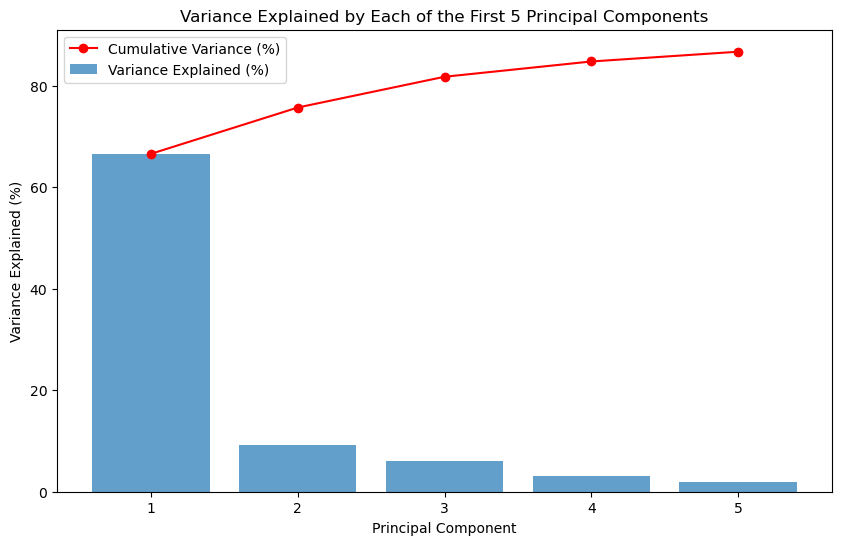

Cumulative variance explained by the first 5 principal components: 86.66%


In [10]:
X_pca, explained_variance_ratio, cumulative_variance = perform_pca_and_plot(final_features_df, n_components=5)

In [11]:
X_pca.shape

(72, 5)

In [12]:
from sklearn.linear_model import Lasso, LassoCV
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
import scipy.stats as stats

def lasso_cross_validation(features, target, risk_series=None, n_splits=5, cv_inner=5, random_state=123):
    """
    Perform nested cross-validation using Lasso regression.
    First, LassoCV is used to find the optimal lambda (alpha),
    then KFold is used to evaluate model performance.
    If risk_series is provided, MAE is also computed for each risk group separately.

    Parameters:
        features (np.ndarray or pd.DataFrame): Feature matrix. If a numpy array is provided,
                                               it will be converted to a DataFrame using the index of the target.
        target (pd.Series): Target variable. Must be a Pandas Series with an index.
        risk_series (pd.Series, optional): Risk variable (risk_for_ad), with the following value mapping:
            - {0,1} are treated as 0 (low risk)
            - {2,3} are treated as 1 (high risk)
        n_splits (int): Number of folds for outer KFold cross-validation.
        cv_inner (int): Number of folds for inner cross-validation (used in LassoCV to select lambda).
        random_state (int): Random seed.

    Returns:
        dict: Dictionary containing the optimal lambda, overall MAE, overall Pearson correlation,
              and mean MAEs for risk group 0 and risk group 1 (if risk_series is provided).
    """
    # If features is not a DataFrame, convert it using the index of the target
    if not isinstance(features, pd.DataFrame):
        if not hasattr(target, "index"):
            raise ValueError("target must be a Pandas Series with an index to align with features")
        features = pd.DataFrame(features, index=target.index)
    
    # Align indices if risk_series is provided (use the intersection of all indices)
    if risk_series is not None:
        common_index = features.index.intersection(target.index).intersection(risk_series.index)
        features = features.loc[common_index].sort_index()
        target = target.loc[common_index].sort_index()
        risk_series = risk_series.loc[common_index].sort_index()
    else:
        common_index = features.index.intersection(target.index)
        features = features.loc[common_index].sort_index()
        target = target.loc[common_index].sort_index()
    
    # Convert to numpy arrays
    X = features.values
    y = target.values

    # Step 1: Use LassoCV with inner cross-validation to select the best lambda
    lasso_cv = LassoCV(cv=cv_inner, random_state=random_state).fit(X, y)
    best_lambda = lasso_cv.alpha_

    # Step 2: Outer cross-validation to evaluate model performance
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    mae_scores = []
    pearson_corr_scores = []
    
    # If risk_series is provided, track MAE for each risk group
    mae_risk0 = []
    mae_risk1 = []
    
    # kf.split returns row indices (corresponding to rows in X)
    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        # If risk_series is provided, get the risk values for the test set
        if risk_series is not None:
            risk_test = risk_series.iloc[test_index].values
            # Map risk values: {0,1} -> 0; {2,3} -> 1
            risk_binary = np.where(np.isin(risk_test, [2, 3]), 1, 0)
        
        # Train the Lasso model with the selected lambda
        lasso = Lasso(alpha=best_lambda, random_state=random_state)
        lasso.fit(X_train, y_train)
        y_pred = lasso.predict(X_test)
        
        # Compute overall MAE
        mae = mean_absolute_error(y_test, y_pred)
        mae_scores.append(mae)
        
        # Compute overall Pearson correlation
        pearson_corr, _ = stats.pearsonr(y_test, y_pred)
        pearson_corr_scores.append(pearson_corr)
        
        # If risk_series is provided, compute MAE separately for each risk group
        if risk_series is not None:
            mask0 = (risk_binary == 0)
            mask1 = (risk_binary == 1)
            
            if np.any(mask0):
                mae0 = mean_absolute_error(y_test[mask0], y_pred[mask0])
                mae_risk0.append(mae0)
            if np.any(mask1):
                mae1 = mean_absolute_error(y_test[mask1], y_pred[mask1])
                mae_risk1.append(mae1)
    
    mean_mae = np.mean(mae_scores)
    mean_pearson_corr = np.mean(pearson_corr_scores)
    
    result = {
        "best_lambda": best_lambda,
        "mean_mae": mean_mae,
        "mean_pearson_corr": mean_pearson_corr
    }
    if risk_series is not None:
        result["mean_mae_risk0"] = np.mean(mae_risk0) if mae_risk0 else np.nan
        result["mean_mae_risk1"] = np.mean(mae_risk1) if mae_risk1 else np.nan
    
    return result


risk = df['risk_for_ad']
risk = risk[risk.index.isin(fa_dict.keys())]
risk = risk.loc[final_features_df.index]

results = lasso_cross_validation(X_pca, final_y, risk_series=risk, n_splits=5, cv_inner=5, random_state=123)
print("Best Lambda (alpha):", results['best_lambda'])
print("Overall Mean MAE:", results['mean_mae'])
print("Overall Mean Pearson Correlation:", results['mean_pearson_corr'])
if "mean_mae_risk0" in results and "mean_mae_risk1" in results:
    print("Mean MAE (risk=0,1 group):", results['mean_mae_risk0'])
    print("Mean MAE (risk=2,3 group):", results['mean_mae_risk1'])


Best Lambda (alpha): 10.461271475037064
Overall Mean MAE: 9.181029612594424
Overall Mean Pearson Correlation: 0.686653008880983
Mean MAE (risk=0,1 group): 8.437621171872966
Mean MAE (risk=2,3 group): 13.09876088592806


## Method 2: PLSRegression

In [15]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
import scipy.stats as stats

def pls_cross_validation_with_risk(
    df_features: pd.DataFrame,
    series_target: pd.Series,
    risk_series: pd.Series,
    n_splits: int = 5,
    cv_inner: int = 4,
    max_components: int = 20,
    random_state: int = 42
) -> dict:
    """
    Perform Partial Least Squares Regression (PLSRegression) using nested cross-validation,
    and compute MAE separately for each risk group.

    Assumes risk_for_ad has values:
        - {0, 1} are treated as risk group 0
        - {2, 3} are treated as risk group 1

    Parameters:
        df_features (pd.DataFrame): Feature matrix, indexed by subject_id or other unique identifier.
        series_target (pd.Series): Target variable (e.g., age), aligned with df_features.
        risk_series (pd.Series): Risk group labels, aligned with df_features.
        n_splits (int): Number of outer folds for cross-validation.
        cv_inner (int): Number of inner folds for selecting optimal number of components.
        max_components (int): Maximum number of components to consider.
        random_state (int): Random seed for reproducibility.

    Returns:
        dict: Dictionary containing:
            "best_n_components": Optimal number of PLS components
            "mean_mae": Overall average MAE from outer CV
            "mean_pearson_corr": Average Pearson correlation from outer CV
            "mean_mae_risk0": Average MAE for risk group 0
            "mean_mae_risk1": Average MAE for risk group 1
    """

    # 1. Align indices & convert to NumPy arrays
    common_index = df_features.index.intersection(series_target.index).intersection(risk_series.index)
    common_index = common_index.sort_values()

    X = df_features.loc[common_index].sort_index().values
    y = series_target.loc[common_index].sort_index().values
    risk_vals = risk_series.loc[common_index].sort_index().values

    # Map risk values to binary: {0,1} -> 0, {2,3} -> 1
    risk_binary = np.where(np.isin(risk_vals, [2, 3]), 1, 0)

    # 2. Inner CV: select best number of components
    inner_kf = KFold(n_splits=cv_inner, shuffle=True, random_state=random_state)
    candidate_mae = []

    for n_comp in range(1, max_components + 1):
        inner_mae_scores = []
        for train_idx, val_idx in inner_kf.split(X):
            X_train_inner, X_val = X[train_idx], X[val_idx]
            y_train_inner, y_val = y[train_idx], y[val_idx]

            pls = PLSRegression(n_components=n_comp)
            pls.fit(X_train_inner, y_train_inner)

            y_pred_val = pls.predict(X_val).ravel()
            mae_val = mean_absolute_error(y_val, y_pred_val)
            inner_mae_scores.append(mae_val)

        candidate_mae.append(np.mean(inner_mae_scores))

    best_n_components = np.argmin(candidate_mae) + 1

    # 3. Outer CV: evaluate overall and per-risk-group performance using best_n_components
    outer_kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    outer_mae_scores = []
    outer_pearson_corr = []

    # Additionally track MAEs for different risk groups
    outer_mae_risk0 = []
    outer_mae_risk1 = []

    for train_idx, test_idx in outer_kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        risk_test = risk_binary[test_idx]

        pls = PLSRegression(n_components=best_n_components)
        pls.fit(X_train, y_train)

        y_pred = pls.predict(X_test).ravel()

        # Overall MAE
        mae_outer = mean_absolute_error(y_test, y_pred)
        outer_mae_scores.append(mae_outer)

        # Overall Pearson correlation
        pearson_corr, _ = stats.pearsonr(y_test, y_pred)
        outer_pearson_corr.append(pearson_corr)

        # Group-wise MAE: risk0 vs. risk1
        mask_risk0 = (risk_test == 0)
        mask_risk1 = (risk_test == 1)

        # Only compute MAE for a group if it has samples
        if np.any(mask_risk0):
            mae_risk0 = mean_absolute_error(y_test[mask_risk0], y_pred[mask_risk0])
            outer_mae_risk0.append(mae_risk0)
        if np.any(mask_risk1):
            mae_risk1 = mean_absolute_error(y_test[mask_risk1], y_pred[mask_risk1])
            outer_mae_risk1.append(mae_risk1)

    mean_mae = np.mean(outer_mae_scores)
    mean_pearson_corr = np.mean(outer_pearson_corr)

    mean_mae_risk0 = np.mean(outer_mae_risk0) if len(outer_mae_risk0) > 0 else np.nan
    mean_mae_risk1 = np.mean(outer_mae_risk1) if len(outer_mae_risk1) > 0 else np.nan

    return {
        "best_n_components": best_n_components,
        "mean_mae": mean_mae,
        "mean_pearson_corr": mean_pearson_corr,
        "mean_mae_risk0": mean_mae_risk0,
        "mean_mae_risk1": mean_mae_risk1
    }


In [16]:


results = pls_cross_validation_with_risk(final_features_df, final_y, risk)
print("Best number of components:", results["best_n_components"])
print("Overall Mean MAE:", results["mean_mae"])
print("Overall Mean Pearson Correlation:", results["mean_pearson_corr"])
print("Mean MAE (risk=0 group):", results["mean_mae_risk0"])
print("Mean MAE (risk=1 group):", results["mean_mae_risk1"])


Best number of components: 4
Overall Mean MAE: 8.488755042507751
Overall Mean Pearson Correlation: 0.7051645462155989
Mean MAE (risk=0 group): 7.707239557287609
Mean MAE (risk=1 group): 15.845599194363757


# LASSO

The training set: risk=0,1

The test set: risk=2,3

In [25]:
# Cell 10-13: Updated code

from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Ensure the 'risk' variable is defined
risk = df['risk_for_ad']
risk = risk[risk.index.isin(fa_dict.keys())]
risk = risk.loc[final_features_df.index]

# Split data into training (risk_for_ad=0,1) and testing (risk_for_ad=2,3)
train_data = final_features_df[risk.isin([0, 1])]
train_target = final_y[risk.isin([0, 1])]

test_data = final_features_df[risk.isin([2, 3])]
test_target = final_y[risk.isin([2, 3])]

# Perform PCA on training data
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_data)

pca = PCA(n_components=15)  # Adjust the number of components as needed
X_train_pca = pca.fit_transform(X_train_scaled)

# Train Lasso with nested cross-validation
lasso_cv = LassoCV(cv=5, random_state=123).fit(X_train_pca, train_target)

# Transform test data using the same scaler and PCA
X_test_scaled = scaler.transform(test_data)
X_test_pca = pca.transform(X_test_scaled)

# Predict on test data
y_pred = lasso_cv.predict(X_test_pca)

# Evaluate performance, including MAE and R-squared
mae = mean_absolute_error(test_target, y_pred)
r2 = r2_score(test_target, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2): {r2:.2f}")
# print the r2 and mae for training data
y_train_pred = lasso_cv.predict(X_train_pca)
mae_train = mean_absolute_error(train_target, y_train_pred)
r2_train = r2_score(train_target, y_train_pred)
print(f"Training Mean Absolute Error (MAE): {mae_train:.2f}")
print(f"Training R-squared (R2): {r2_train:.2f}")


Mean Absolute Error (MAE): 8.08
R-squared (R2): -1.18
Training Mean Absolute Error (MAE): 6.11
Training R-squared (R2): 0.72


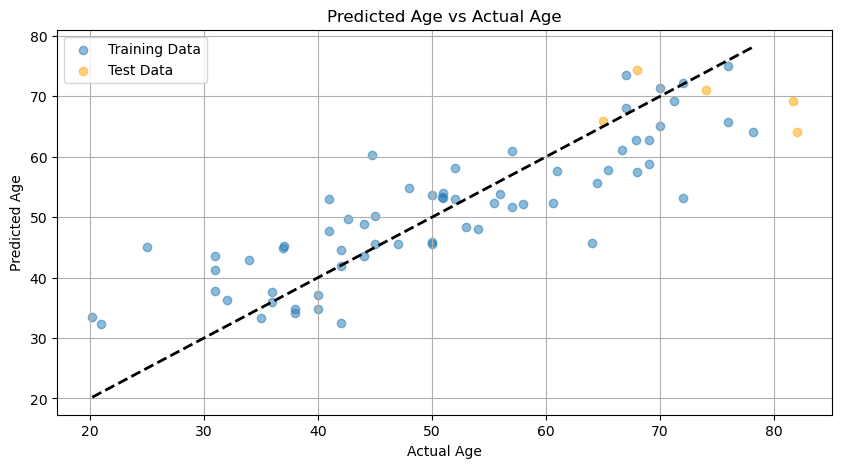

In [26]:
# Visualize predicted age vs. actual age for training data and test data on the same plot
plt.figure(figsize=(10, 5))
plt.scatter(train_target, y_train_pred, label='Training Data', alpha=0.5)
plt.scatter(test_target, y_pred, label='Test Data', alpha=0.5, color='orange')
plt.plot([min(train_target), max(train_target)], [min(train_target), max(train_target)], 'k--', lw=2)
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title('Predicted Age vs Actual Age')
plt.legend()
plt.grid()
plt.show()


## Importance

In [31]:
# Step 1: Retrieve PCA components and Lasso coefficients
pca_components = pca.components_  # Shape: (n_components, n_original_features)
lasso_coefficients = lasso_cv.coef_  # Shape: (n_components,)

# Step 2: Map importance back to original features
feature_importance = np.abs(np.dot(lasso_coefficients, pca_components))

# Step 3: Normalize the importance (optional, for better visualization)
feature_importance /= np.sum(feature_importance)
importance_df = pd.DataFrame({'Importance': feature_importance})

# Step 5: Use the region_list and bio_features to get the original feature names
# Each region has 21 values, and these are concatenated in the order of region_list
# bio_features has the same order as the original DataFrame
region_names = []
for hemi in hemis:
    for region in region_list:
        for i in range(1, 22):  # Each region has 21 values
            region_names.append(f"{hemi}_{region}_{i}")
# Add the bio features names to the region names
region_names += bio_features.columns.tolist()
importance_df['Feature'] = region_names[:len(importance_df)]  # Ensure the length matches
importance_df = importance_df.sort_values(by='Importance', ascending=False)
# Print top 40 names of the features
print(importance_df.head(40))
# Save the feature importance DataFrame to a CSV file
importance_df.to_csv('feature_importance_fa.csv', index=False)


      Importance                   Feature
1444    0.002107               AVLT_Trial6
1460    0.002097                     ufov2
1141    0.002058          rh_postcentral_8
1142    0.002057          rh_postcentral_9
1140    0.002034          rh_postcentral_7
1143    0.002030         rh_postcentral_10
1182    0.002010           rh_precentral_7
1461    0.001999                     ufov3
1181    0.001995           rh_precentral_6
1183    0.001991           rh_precentral_8
1139    0.001982          rh_postcentral_6
1446    0.001978           RAVLT_IMMEDIATE
1144    0.001977         rh_postcentral_11
450     0.001955  lh_posteriorcingulate_10
449     0.001950   lh_posteriorcingulate_9
451     0.001947  lh_posteriorcingulate_11
1184    0.001945           rh_precentral_9
1180    0.001937           rh_precentral_5
1445    0.001937               AVLT_Trial7
448     0.001934   lh_posteriorcingulate_8
452     0.001928  lh_posteriorcingulate_12
447     0.001908   lh_posteriorcingulate_7
1145    0.0

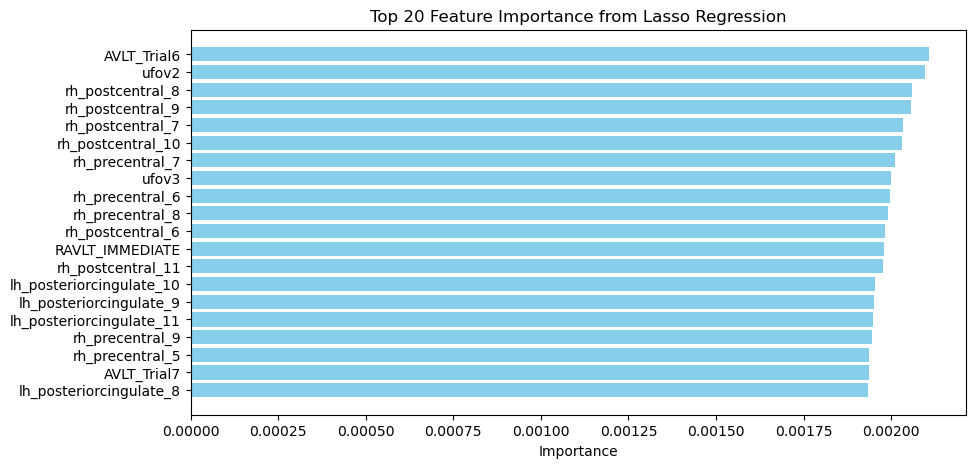

In [36]:
top_num = 20
# Optional: Plot the top_num feature importance
plt.figure(figsize=(10, 5))
plt.barh(importance_df['Feature'][:top_num], importance_df['Importance'][:top_num], color='skyblue')
plt.xlabel('Importance')
plt.title(f'Top {top_num} Feature Importance from Lasso Regression')
plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature at the top
plt.show()


{'bankssts': np.float64(0.02708378631036977), 'caudalanteriorcingulate': np.float64(0.05570758286349488), 'caudalmiddlefrontal': np.float64(0.03970242338573586), 'cuneus': np.float64(0.032974910955103263), 'entorhinal': np.float64(0.04672695149873403), 'fusiform': np.float64(0.028846359657544583), 'inferiorparietal': np.float64(0.01546769845046112), 'inferiortemporal': np.float64(0.030056398479380055), 'isthmuscingulate': np.float64(0.013204058278693274), 'lateraloccipital': np.float64(0.01743458857394856), 'lateralorbitofrontal': np.float64(0.026625785929774534), 'lingual': np.float64(0.01717936211542797), 'medialorbitofrontal': np.float64(0.031145920937098216), 'middletemporal': np.float64(0.014375841931642047), 'parahippocampal': np.float64(0.0435641269962863), 'paracentral': np.float64(0.03348701035377049), 'parsopercularis': np.float64(0.018694154122195626), 'parsorbitalis': np.float64(0.014544567501634718), 'parstriangularis': np.float64(0.016331986177643115), 'pericalcarine': np

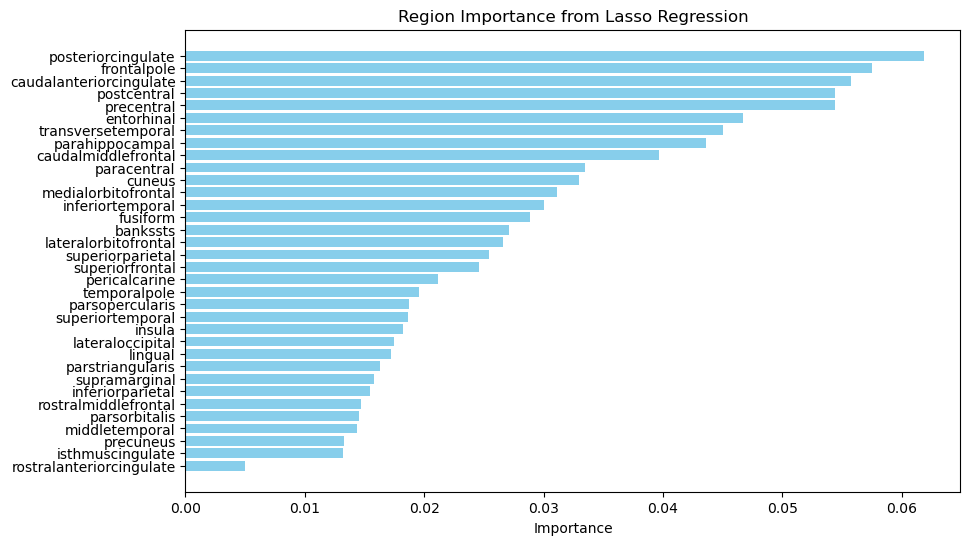

In [38]:
# Count the the importance of each region
region_importance = {}
for region in region_list:
    region_importance[region] = 0
for i in range(len(importance_df)):
    feature = importance_df['Feature'][i]
    for region in region_list:
        if region in feature:
            region_importance[region] += importance_df['Importance'][i]
# Print the importance of each region
print(region_importance)
# Sort the regions by their importance in descending order
sorted_region_importance = dict(sorted(region_importance.items(), key=lambda item: item[1], reverse=True))

# Plot the importance of each region from top to bottom
plt.figure(figsize=(10, 6))
plt.barh(list(sorted_region_importance.keys()), list(sorted_region_importance.values()), color='skyblue')
plt.xlabel('Importance')
plt.title('Region Importance from Lasso Regression')
plt.gca().invert_yaxis()  # Invert y-axis to show the most important region at the top
plt.show()
# Save the region importance to a CSV file
region_importance_df = pd.DataFrame(region_importance.items(), columns=['Region', 'Importance'])
region_importance_df.to_csv('region_importance_fa.csv', index=False)

# XGBoost

The training set: risk = 0,1

The test set: risk = 2,3

XGBoost Mean Absolute Error (MAE): 8.59
XGBoost R-squared (R2): -1.01
XGBoost Training Mean Absolute Error (MAE): 0.00
XGBoost Training R-squared (R2): 1.00


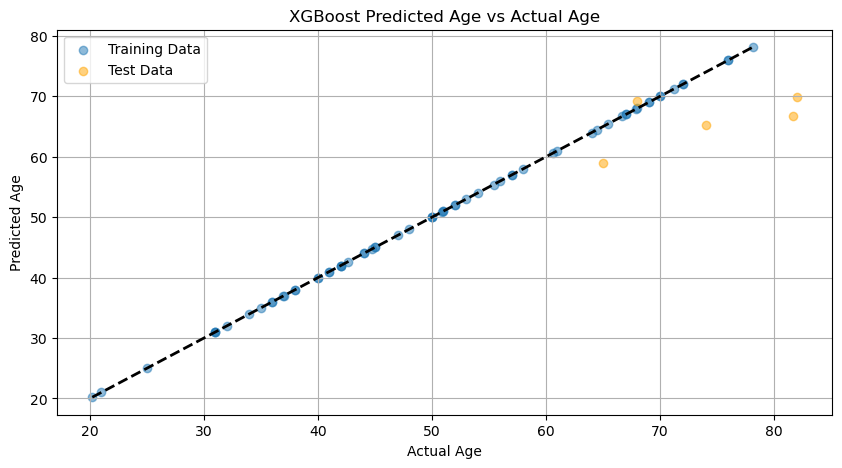

In [20]:
# Use XGBoost for feature importance
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# Split the data into training and testing sets
# Use the same train_data and test_data as Lasso regression
risk = df['risk_for_ad']
risk = risk[risk.index.isin(fa_dict.keys())]
risk = risk.loc[final_features_df.index]
train_data = final_features_df[risk.isin([0, 1])]
train_target = final_y[risk.isin([0, 1])]
test_data = final_features_df[risk.isin([2, 3])]
test_target = final_y[risk.isin([2, 3])]

# Perform PCA on training data
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_data)
pca = PCA(n_components=15)  # Adjust the number of components as needed
X_train_pca = pca.fit_transform(X_train_scaled)
# Transform test data using the same scaler and PCA
X_test_scaled = scaler.transform(test_data)
X_test_pca = pca.transform(X_test_scaled)

# Train XGBoost model
xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train_pca, train_target)

# Predict on test data
y_pred_xgb = xgb_model.predict(X_test_pca)

# Evaluate performance, including MAE and R-squared
mae_xgb = mean_absolute_error(test_target, y_pred_xgb)
r2_xgb = r2_score(test_target, y_pred_xgb)
print(f"XGBoost Mean Absolute Error (MAE): {mae_xgb:.2f}")
print(f"XGBoost R-squared (R2): {r2_xgb:.2f}")
# Print the r2 and mae for training data
y_train_pred_xgb = xgb_model.predict(X_train_pca)
mae_train_xgb = mean_absolute_error(train_target, y_train_pred_xgb)
r2_train_xgb = r2_score(train_target, y_train_pred_xgb)
print(f"XGBoost Training Mean Absolute Error (MAE): {mae_train_xgb:.2f}")
print(f"XGBoost Training R-squared (R2): {r2_train_xgb:.2f}")

# Visualize predicted age vs. actual age for training data and test data on the same plot
plt.figure(figsize=(10, 5))
plt.scatter(train_target, y_train_pred_xgb, label='Training Data', alpha=0.5)
plt.scatter(test_target, y_pred_xgb, label='Test Data', alpha=0.5, color='orange')
plt.plot([min(train_target), max(train_target)], [min(train_target), max(train_target)], 'k--', lw=2)
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title('XGBoost Predicted Age vs Actual Age')
plt.legend()
plt.grid()
plt.show()


## Importance

      Importance                   Feature
177     0.002241    lh_isthmuscingulate_10
178     0.002232    lh_isthmuscingulate_11
176     0.002224     lh_isthmuscingulate_9
179     0.002200    lh_isthmuscingulate_12
175     0.002186     lh_isthmuscingulate_8
180     0.002145    lh_isthmuscingulate_13
174     0.002137     lh_isthmuscingulate_7
173     0.002080     lh_isthmuscingulate_6
181     0.002074    lh_isthmuscingulate_14
1434    0.002017                       BMI
172     0.002017     lh_isthmuscingulate_5
1027    0.001990     rh_parahippocampal_20
1026    0.001990     rh_parahippocampal_19
182     0.001988    lh_isthmuscingulate_15
1028    0.001972     rh_parahippocampal_21
1025    0.001971     rh_parahippocampal_18
171     0.001959     lh_isthmuscingulate_4
1433    0.001948                    Weight
1024    0.001940     rh_parahippocampal_17
170     0.001911     lh_isthmuscingulate_3
1023    0.001899     rh_parahippocampal_16
183     0.001884    lh_isthmuscingulate_16
169     0.0

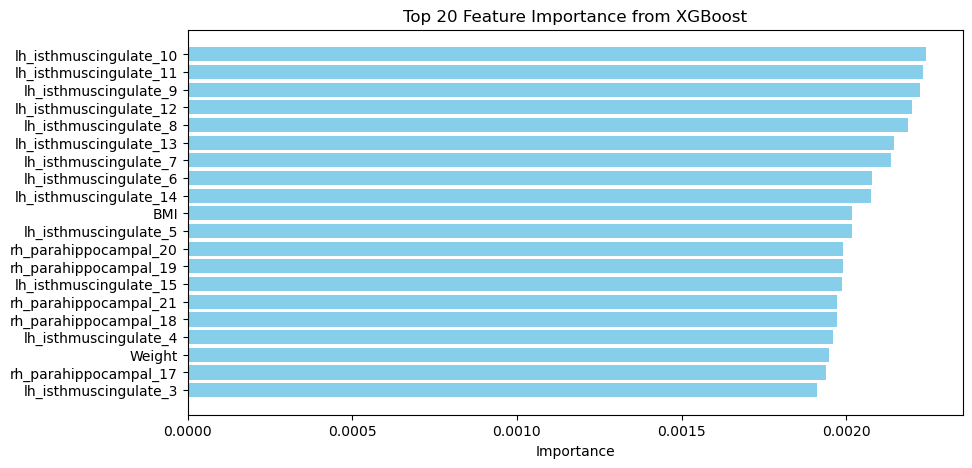

{'bankssts': np.float64(0.032172747329436334), 'caudalanteriorcingulate': np.float64(0.01873977008513048), 'caudalmiddlefrontal': np.float64(0.05167335555896098), 'cuneus': np.float64(0.022994638890026745), 'entorhinal': np.float64(0.013282308137312066), 'fusiform': np.float64(0.0630010992478792), 'inferiorparietal': np.float64(0.016164253296599217), 'inferiortemporal': np.float64(0.02754875479777597), 'isthmuscingulate': np.float64(0.05812108958925227), 'lateraloccipital': np.float64(0.009529164879091126), 'lateralorbitofrontal': np.float64(0.006691121660621625), 'lingual': np.float64(0.04054582249729585), 'medialorbitofrontal': np.float64(0.01643116148745348), 'middletemporal': np.float64(0.02688217717776991), 'parahippocampal': np.float64(0.05639985204203786), 'paracentral': np.float64(0.037458041757174265), 'parsopercularis': np.float64(0.02352536157589571), 'parsorbitalis': np.float64(0.025048189002638874), 'parstriangularis': np.float64(0.030618759748094318), 'pericalcarine': np.

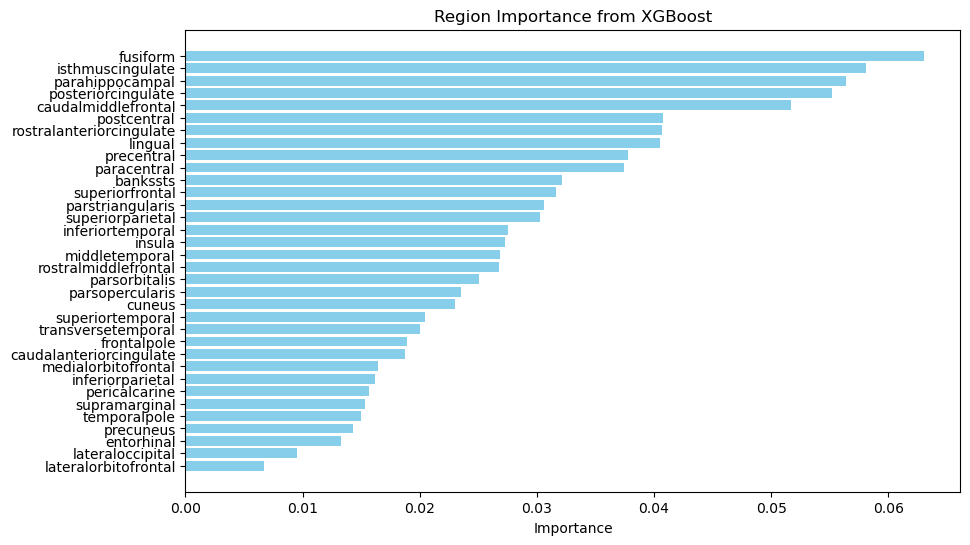

In [21]:
# Show feature importance

pca_components = pca.components_  # Shape: (n_components, n_original_features)
xgb_importance = xgb_model.feature_importances_  # Shape: (n_components,)
# Map importance back to original features
feature_importance_xgb = np.abs(np.dot(xgb_importance, pca_components))
# Normalize the importance (optional, for better visualization)
feature_importance_xgb /= np.sum(feature_importance_xgb)
importance_df_xgb = pd.DataFrame({'Importance': feature_importance_xgb})
# Use the region_list and bio_features to get the original feature names
region_names = []
for hemi in hemis:
    for region in region_list:
        for i in range(1, 22):  # Each region has 21 values
            region_names.append(f"{hemi}_{region}_{i}")
# Add the bio features names to the region names
region_names += bio_features.columns.tolist()
# Add the feature names to the importance DataFrame
importance_df_xgb['Feature'] = region_names[:len(importance_df_xgb)]  # Ensure the length matches
importance_df_xgb = importance_df_xgb.sort_values(by='Importance', ascending=False)
# Print top 40 names of the features
print(importance_df_xgb.head(40))
# Save the feature importance DataFrame to a CSV file
importance_df_xgb.to_csv('feature_importance_xgb.csv', index=False)
# Optional: Plot the top_num feature importance
top_num = 20
plt.figure(figsize=(10, 5))
plt.barh(importance_df_xgb['Feature'][:top_num], importance_df_xgb['Importance'][:top_num], color='skyblue')
plt.xlabel('Importance')
plt.title(f'Top {top_num} Feature Importance from XGBoost')
plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature at the top
plt.show()
# Count the the importance of each region
region_importance_xgb = {}
for region in region_list:
    region_importance_xgb[region] = 0
for i in range(len(importance_df_xgb)):
    feature = importance_df_xgb['Feature'][i]
    for region in region_list:
        if region in feature:
            region_importance_xgb[region] += importance_df_xgb['Importance'][i]
# Print the importance of each region
print(region_importance_xgb)
# Sort the regions by their importance in descending order
sorted_region_importance_xgb = dict(sorted(region_importance_xgb.items(), key=lambda item: item[1], reverse=True))
# Plot the importance of each region from top to bottom
plt.figure(figsize=(10, 6))
plt.barh(list(sorted_region_importance_xgb.keys()), list(sorted_region_importance_xgb.values()), color='skyblue')
plt.xlabel('Importance')
plt.title('Region Importance from XGBoost')
plt.gca().invert_yaxis()  # Invert y-axis to show the most important region at the top
plt.show()


# XGBoost

The training set: risk = 0,1

The test set: risk = 2,3

Mean Absolute Error (MAE): 7.23
R-squared (R2): 0.77
Mean Absolute Error (MAE) for risk_for_ad=0,1: 6.68
R-squared (R2) for risk_for_ad=0,1: 0.64
Mean Absolute Error (MAE) for risk_for_ad=2,3: 8.67
R-squared (R2) for risk_for_ad=2,3: -0.69
Training Mean Absolute Error (MAE): 0.00
Training R-squared (R2): 1.00


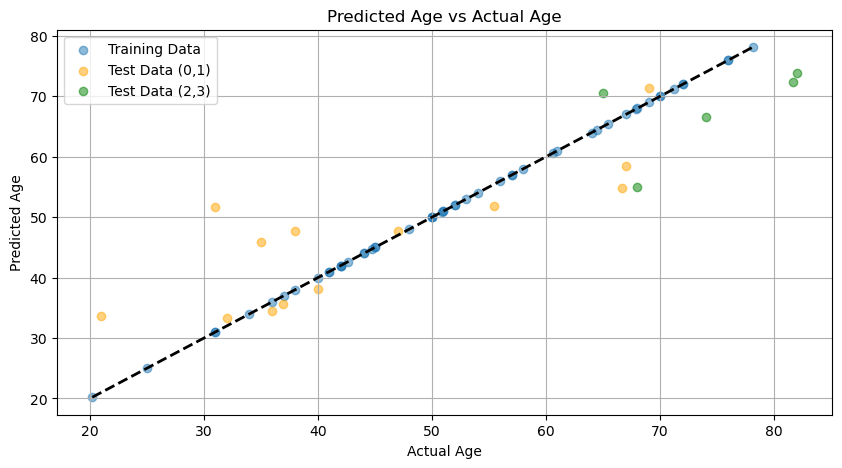

In [10]:
# Use XGBoost for feature importance
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# Ensure the 'risk' variable is defined
risk = df['risk_for_ad']
risk = risk[risk.index.isin(fa_dict.keys())]
risk = risk.loc[final_features_df.index]

# Split data into training (risk_for_ad=0,1) and testing (risk_for_ad=2,3)

# Filter risk_for_ad=0,1 data
train_data_01 = final_features_df[risk.isin([0, 1])]
train_target_01 = final_y[risk.isin([0, 1])]

# Split 1/5 of risk_for_ad=0,1 data as part of test data
train_data_01, test_data_01, train_target_01, test_target_01 = train_test_split(
    train_data_01, train_target_01, test_size=0.2, random_state=42
)

# Use all risk_for_ad=2,3 data as test data
test_data_23 = final_features_df[risk.isin([2, 3])]
test_target_23 = final_y[risk.isin([2, 3])]

# Combine test data from both splits
test_data = pd.concat([test_data_01, test_data_23])
test_target = pd.concat([test_target_01, test_target_23])

# Remaining training data
train_data = train_data_01
train_target = train_target_01

# Perform PCA on training data
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_data)
X_test_scaled = scaler.transform(test_data)

pca = PCA(n_components=15)  # Adjust the number of components as needed
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Train XGBoost model
xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train_pca, train_target)

# Predict on test data
y_pred = xgb_model.predict(X_test_pca)

# Evaluate performance, including MAE and R-squared
mae = mean_absolute_error(test_target, y_pred)
r2 = r2_score(test_target, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Ensure the lengths of predictions and targets match
y_pred_01 = y_pred[:len(test_target_01)]
y_pred_23 = y_pred[len(test_target_01):]

# Print MAE and R2 for risk_for_ad=0,1 group and risk_for_ad=2,3 group
mae_01 = mean_absolute_error(test_target_01, y_pred_01)
r2_01 = r2_score(test_target_01, y_pred_01)
print(f"Mean Absolute Error (MAE) for risk_for_ad=0,1: {mae_01:.2f}")
print(f"R-squared (R2) for risk_for_ad=0,1: {r2_01:.2f}")

# Print MAE and R2 for risk_for_ad=2,3 group
mae_23 = mean_absolute_error(test_target_23, y_pred_23)
r2_23 = r2_score(test_target_23, y_pred_23)
print(f"Mean Absolute Error (MAE) for risk_for_ad=2,3: {mae_23:.2f}")
print(f"R-squared (R2) for risk_for_ad=2,3: {r2_23:.2f}")

# Print the r2 and mae for training data
y_train_pred = xgb_model.predict(X_train_pca)
mae_train = mean_absolute_error(train_target, y_train_pred)
r2_train = r2_score(train_target, y_train_pred)
print(f"Training Mean Absolute Error (MAE): {mae_train:.2f}")
print(f"Training R-squared (R2): {r2_train:.2f}")

# Visualize predicted age vs. actual age for training data and test data on the same plot
plt.figure(figsize=(10, 5))
plt.scatter(train_target, y_train_pred, label='Training Data', alpha=0.5)
plt.scatter(test_target_01, y_pred[:len(test_target_01)], label='Test Data (0,1)', alpha=0.5, color='orange')
plt.scatter(test_target_23, y_pred[len(test_target_01):], label='Test Data (2,3)', alpha=0.5, color='green')
plt.plot([min(train_target), max(train_target)], [min(train_target), max(train_target)], 'k--', lw=2)
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title('Predicted Age vs Actual Age')
plt.legend()
plt.grid()
plt.show()


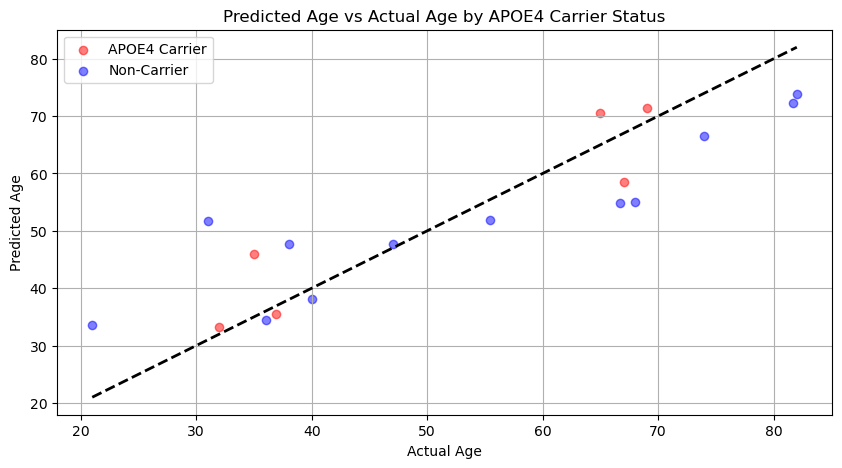

In [11]:
# Show the difference of predicted age in APOE4 carriage, sex
# Plot the predicted age vs actual age for APOE4 carriage
# The 'genotype' column in df contains the APOE4 carriage information: 'APOE34', 'APOE33', 'APOE23' etc.
# We will create a new column 'APOE4_carrier' to indicate whether the subject is an APOE4 carrier or not
df['APOE4_carrier'] = df['genotype'].apply(lambda x: 1 if '4' in x else 0)
# Filter the data to include only subjects in the test set
test_data = test_data.loc[test_target.index]
test_target = test_target.loc[test_data.index]
# Add the 'APOE4_carrier' information to the test data
test_data['APOE4_carrier'] = df['APOE4_carrier'].loc[test_data.index]
# Create a scatter plot of predicted age vs actual age, colored by APOE4 carrier status
plt.figure(figsize=(10, 5))
plt.scatter(test_target[test_data['APOE4_carrier'] == 1], y_pred[test_data['APOE4_carrier'] == 1], label='APOE4 Carrier', alpha=0.5, color='red')
plt.scatter(test_target[test_data['APOE4_carrier'] == 0], y_pred[test_data['APOE4_carrier'] == 0], label='Non-Carrier', alpha=0.5, color='blue')
plt.plot([min(test_target), max(test_target)], [min(test_target), max(test_target)], 'k--', lw=2)
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title('Predicted Age vs Actual Age by APOE4 Carrier Status')
plt.legend()
plt.grid()
plt.show()

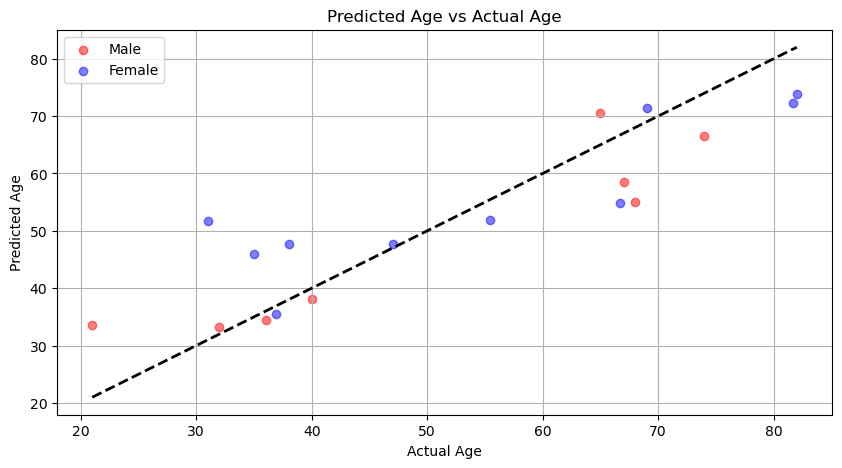

In [12]:
# Plot the predicted age vs actual age for sex
# The 'sex' column in df contains: 'M' or 'F'

test_data['sex'] = df['sex'].loc[test_data.index]
plt.figure(figsize=(10, 5))
plt.scatter(test_target[test_data['sex'] == 'M'], y_pred[test_data['sex'] == 'M'], label='Male', alpha=0.5, color='red')
plt.scatter(test_target[test_data['sex'] == 'F'], y_pred[test_data['sex'] == 'F'], label='Female', alpha=0.5, color='blue')
plt.plot([min(test_target), max(test_target)], [min(test_target), max(test_target)], 'k--', lw=2)
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title('Predicted Age vs Actual Age')
plt.legend()
plt.grid()
plt.show()

# Importance

In [16]:
# Show feature importance
pca_components = pca.components_  # Shape: (n_components, n_original_features)
xgb_importance = xgb_model.feature_importances_  # Shape: (n_components,)
# Map importance back to original features
feature_importance = np.abs(np.dot(xgb_importance, pca_components))
# Normalize the importance (optional, for better visualization)
feature_importance /= np.sum(feature_importance)
importance_df = pd.DataFrame({'Importance': feature_importance})

# Use the region_list and bio_features to get the original feature names
region_names = []
for hemi in hemis:
    for region in region_list:
        for i in range(1, 22):  # Each region has 21 values
            region_names.append(f"{hemi}_{region}_{i}")
# Add the bio features names to the region names
region_names += bio_features.columns.tolist()
# Ensure the length matches
importance_df['Feature'] = region_names[:len(importance_df)]  # Ensure the length matches
importance_df = importance_df.sort_values(by='Importance', ascending=False)
# Print top 40 names of the features
print(importance_df.head(40))
# Save the feature importance DataFrame to a CSV file
importance_df.to_csv('feature_importance_xgboost_fa.csv', index=False)

      Importance                   Feature
1461    0.002481                     ufov3
1427    0.002192              rh_insula_21
760     0.002133  rh_caudalmiddlefrontal_5
761     0.002127  rh_caudalmiddlefrontal_6
1017    0.002090     rh_parahippocampal_10
759     0.002089  rh_caudalmiddlefrontal_4
1018    0.002087     rh_parahippocampal_11
1016    0.002082      rh_parahippocampal_9
762     0.002080  rh_caudalmiddlefrontal_7
1019    0.002080     rh_parahippocampal_12
1020    0.002071     rh_parahippocampal_13
1021    0.002059     rh_parahippocampal_14
1015    0.002056      rh_parahippocampal_8
1022    0.002036     rh_parahippocampal_15
1023    0.002008     rh_parahippocampal_16
1014    0.002006      rh_parahippocampal_7
763     0.002004  rh_caudalmiddlefrontal_8
758     0.001984  rh_caudalmiddlefrontal_3
1007    0.001981      rh_middletemporal_21
1024    0.001969     rh_parahippocampal_17
1426    0.001951              rh_insula_20
305     0.001947     lh_parahippocampal_12
306     0.0

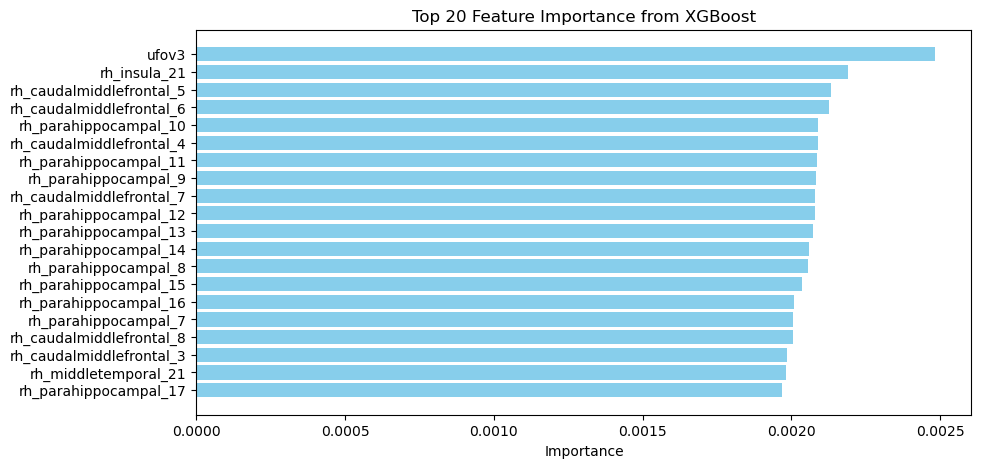

In [17]:
# Plot the top_num feature importance
top_num = 20
plt.figure(figsize=(10, 5))
plt.barh(importance_df['Feature'][:top_num], importance_df['Importance'][:top_num], color='skyblue')
plt.xlabel('Importance')
plt.title(f'Top {top_num} Feature Importance from XGBoost')
plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature at the top
plt.show()

{'bankssts': np.float64(0.019678879775085124), 'caudalanteriorcingulate': np.float64(0.018568922204598305), 'caudalmiddlefrontal': np.float64(0.06536959457678994), 'cuneus': np.float64(0.025434619950666877), 'entorhinal': np.float64(0.034823384925932656), 'fusiform': np.float64(0.024855904151153754), 'inferiorparietal': np.float64(0.009841967882816934), 'inferiortemporal': np.float64(0.04241679159532556), 'isthmuscingulate': np.float64(0.016406642004895326), 'lateraloccipital': np.float64(0.018511682669669124), 'lateralorbitofrontal': np.float64(0.03488728852146851), 'lingual': np.float64(0.009955346272995692), 'medialorbitofrontal': np.float64(0.02237621352500831), 'middletemporal': np.float64(0.034047259307867526), 'parahippocampal': np.float64(0.07220707566467457), 'paracentral': np.float64(0.04224367130556711), 'parsopercularis': np.float64(0.030812598458551107), 'parsorbitalis': np.float64(0.038854419297423094), 'parstriangularis': np.float64(0.01987689941689108), 'pericalcarine':

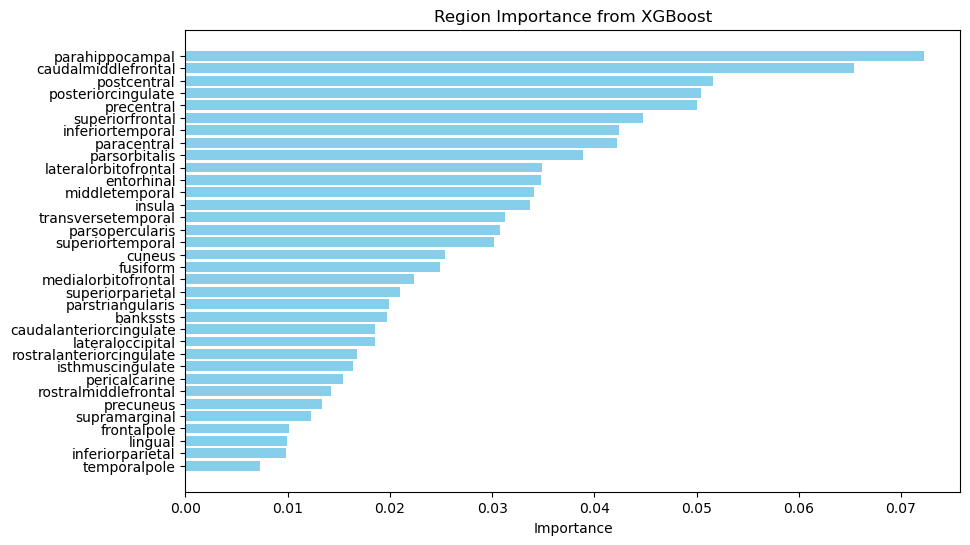

In [18]:
# Count the the importance of each region
region_importance = {}
for region in region_list:
    region_importance[region] = 0
for i in range(len(importance_df)):
    feature = importance_df['Feature'][i]
    for region in region_list:
        if region in feature:
            region_importance[region] += importance_df['Importance'][i]
# Print the importance of each region
print(region_importance)
# Sort the regions by their importance in descending order
sorted_region_importance = dict(sorted(region_importance.items(), key=lambda item: item[1], reverse=True))
# Plot the importance of each region from top to bottom
plt.figure(figsize=(10, 6))
plt.barh(list(sorted_region_importance.keys()), list(sorted_region_importance.values()), color='skyblue')
plt.xlabel('Importance')
plt.title('Region Importance from XGBoost')
plt.gca().invert_yaxis()  # Invert y-axis to show the most important region at the top
plt.show()
# Save the region importance to a CSV file
region_importance_df = pd.DataFrame(region_importance.items(), columns=['Region', 'Importance'])
region_importance_df.to_csv('region_importance_xgboost_fa.csv', index=False)

# MLP

d:\Anaconda\install\envs\column_analyse\Lib\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch [100/1000], Loss: 239.6754
Epoch [200/1000], Loss: 237.5030
Epoch [300/1000], Loss: 240.7409
Epoch [400/1000], Loss: 235.8594
Epoch [500/1000], Loss: 241.7245
Epoch [600/1000], Loss: 236.7267
Epoch [700/1000], Loss: 242.0197
Epoch [800/1000], Loss: 232.7990
Epoch [900/1000], Loss: 235.4133
Epoch [1000/1000], Loss: 237.8718
Mean Absolute Error (MAE): 20.05
R-squared (R2): -8.04
Training Mean Absolute Error (MAE): 12.02
Training R-squared (R2): 0.02


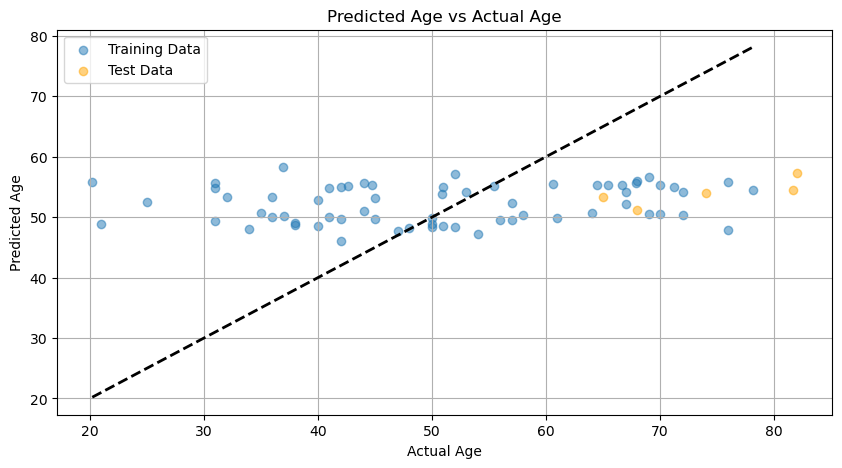

In [11]:
# Use MLP for feature importance
from torch import nn  
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import torch
import torch.nn.functional as F
import torch.optim as optim

# Ensure the 'risk' variable is defined
risk = df['risk_for_ad']
risk = risk[risk.index.isin(fa_dict.keys())]
risk = risk.loc[final_features_df.index]
# Split data into training (risk_for_ad=0,1) and testing (risk_for_ad=2,3)
train_data = final_features_df[risk.isin([0, 1])]
train_target = final_y[risk.isin([0, 1])]

test_data = final_features_df[risk.isin([2, 3])]
test_target = final_y[risk.isin([2, 3])]

# Define the MLP model
class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, 2048)
        self.ReLU1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(2048, 1024)
        self.ReLU2 = nn.ReLU()
        self.fc3 = nn.Linear(1024, 512)
        self.ReLU3 = nn.ReLU()
        self.fc4 = nn.Linear(512, 256)
        self.ReLU4 = nn.ReLU()
        self.fc5 = nn.Linear(256, 64)
        self.ReLU5 = nn.ReLU()
        self.fc7 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.ReLU1(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.ReLU2(x)
        x = self.fc3(x)
        x = self.ReLU3(x)
        x = self.fc4(x)
        x = self.ReLU4(x)
        x = self.fc5(x)
        x = self.ReLU5(x)
        x = self.fc7(x)
        return x

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(train_data.values, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(train_target.values, dtype=torch.float32).to(device)

X_test_tensor = torch.tensor(test_data.values, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(test_target.values, dtype=torch.float32).to(device)

model = MLP(X_train_tensor.shape[1]).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()
# Training loop
num_epochs = 1000
batch_size = 32
num_batches = len(X_train_tensor) // batch_size
for epoch in range(num_epochs):
    model.train()
    for i in range(num_batches):
        start = i * batch_size
        end = start + batch_size
        X_batch = X_train_tensor[start:end].to(device)
        y_batch = y_train_tensor[start:end].to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')
# Evaluate the model on the test set
model.eval()
with torch.no_grad():
    y_pred_tensor = model(X_test_tensor.to(device))
    y_pred = y_pred_tensor.cpu().detach().numpy()
    y_test = y_test_tensor.cpu().detach().numpy()
    # Calculate MAE and R-squared
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"R-squared (R2): {r2:.2f}")
# Print the r2 and mae for training data
y_train_pred_tensor = model(X_train_tensor.to(device))
y_train_pred = y_train_pred_tensor.cpu().detach().numpy()
mae_train = mean_absolute_error(y_train_tensor.cpu().detach().numpy(), y_train_pred)
r2_train = r2_score(y_train_tensor.cpu().detach().numpy(), y_train_pred)
print(f"Training Mean Absolute Error (MAE): {mae_train:.2f}")
print(f"Training R-squared (R2): {r2_train:.2f}")
# Visualize predicted age vs. actual age for training data and test data on the same plot
plt.figure(figsize=(10, 5))
plt.scatter(train_target, y_train_pred, label='Training Data', alpha=0.5)
plt.scatter(test_target, y_pred, label='Test Data', alpha=0.5, color='orange')
plt.plot([min(train_target), max(train_target)], [min(train_target), max(train_target)], 'k--', lw=2)
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title('Predicted Age vs Actual Age')
plt.legend()
plt.grid()
plt.show()